# Lab 073 · When SSL actually helps

Implement the experiment before interpreting the curve. Three TODOs feed fresh execution. CPU protocol: 3 real datasets × 3 paired seeds × 5 budgets × 6 arms. Fixed 40 pretraining / 60 supervised epochs. Original benchmark reproduction: INCOMPARABLE. Read the full self-contained explanation below, then implement the three tasks.

[Lesson](../lessons/0073-when-ssl-helps.html) · [Contract](../labs/l073-reproduction.md)

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Start with retrieval

Without reopening Lesson 72, write three answers: What does SCARF predict during pretraining? Which parameters move in a frozen probe? Can unlabeled test rows enter an inductive training pipeline? Keep your answers for tutor review.



**Your tangible win:** build a fair label-budget curve, compute paired gains, and explain whether the measured grid contains a crossover. Finishing the notebook is not the same as demonstrating that explanation.

[Lesson 71](../lessons/0071-vime-masked-tabular-ssl.html) introduced learning by repairing corrupted rows. [Lesson 72](../lessons/0072-scarf-subtab-contrastive-views.html) introduced learning by recognizing companion views. Here the question changes: when does that additional training help the prediction task? This is an experimental-design lesson; it introduces no new model.

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 073</p><p><strong>Build on what you know.</strong> Lessons 71–72 supplied mechanisms. Lessons 56 and 60 supplied dataset-balanced comparison discipline. Here the intervention is pretraining, so matching the supervised architecture is essential.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0074-carte-cross-table-transfer.html">Lesson 74</a> changes a different assumption: the source and target can have different schemas. A label-efficiency gain within one fixed schema does not answer that transfer question.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>



## Make “SSL helps” a measurable statement

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">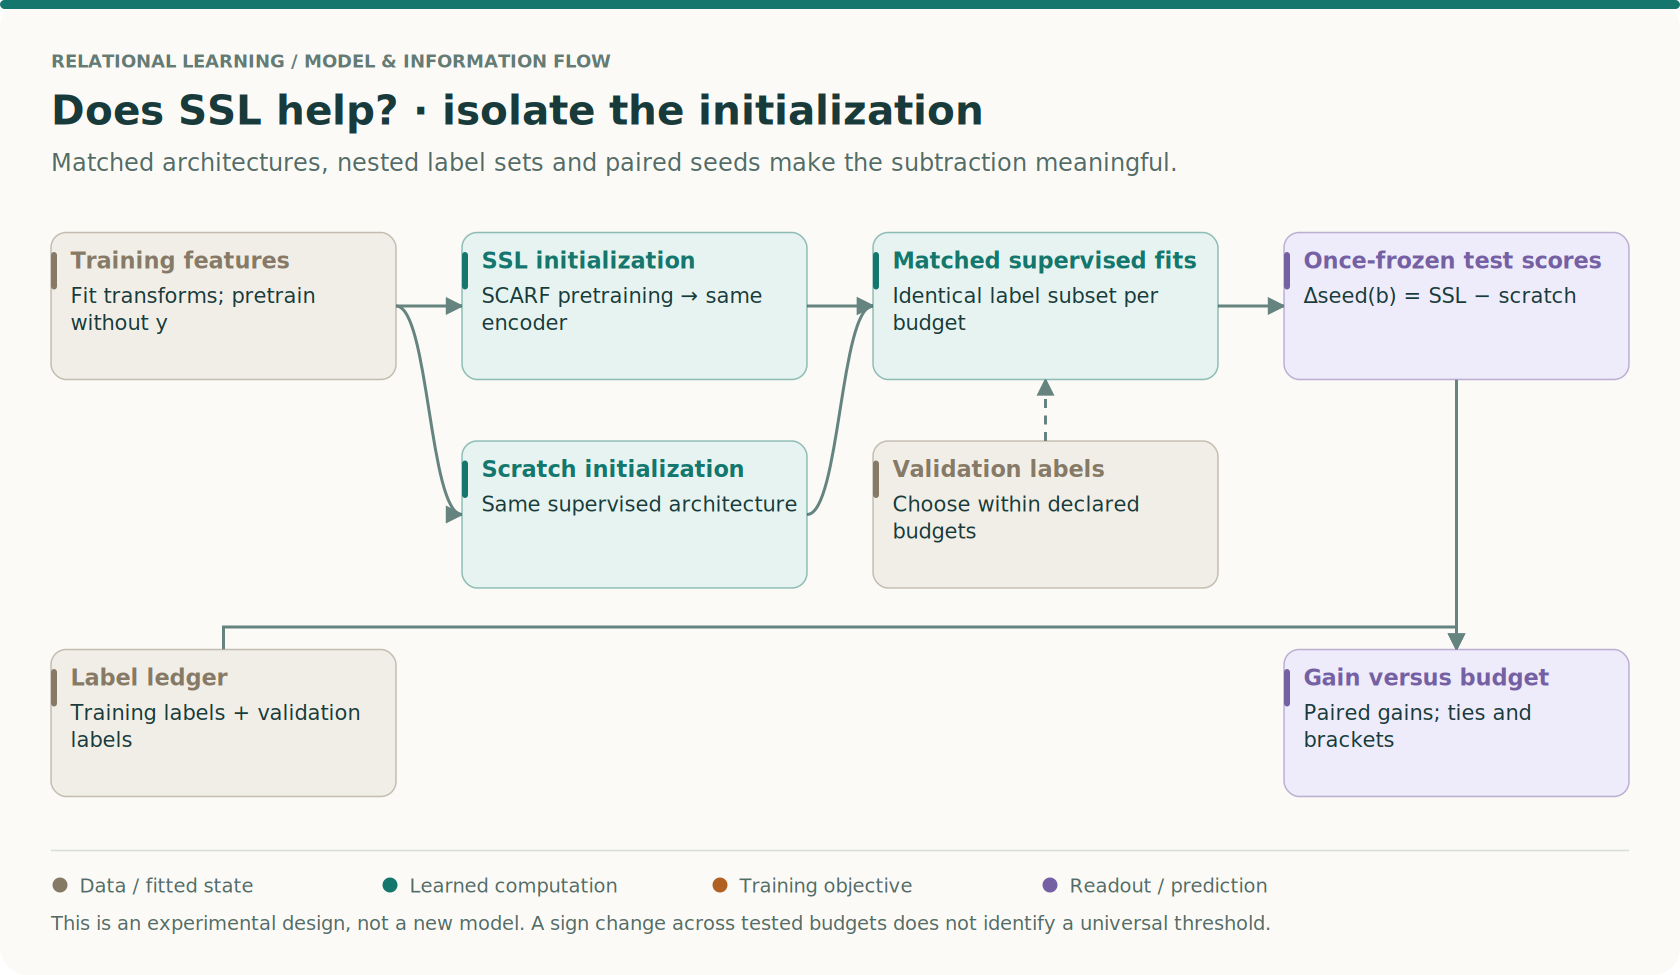</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Paper reading: distinguish the claim from its conditions

Use [SCARF §4.3](https://arxiv.org/html/2106.15147v2#S4.SS3) to identify the label-limited experiment, and [Oliver et al.'s evaluation study](https://arxiv.org/html/1804.09170v2) to ask what makes an SSL comparison informative. Record the supervised baseline, access to unlabeled examples, and validation procedure. This lesson's budget sweep is a local controlled experiment; its crossover analysis is not an additional claim made by those papers.

### Construct one valid point on the curve

1. **Freeze the row split first.** Fit scaling on training rows, then hide training labels from the pretrainer. This makes “unlabeled” a statement about access to y, not permission to use arbitrary future or test rows.
2. **Create a nested label ladder.** If the training budget grows from 20 to 40 labels, keep the original 20. Otherwise the curve changes both label count and which examples are available. Repeat the ladder across declared seeds to expose this dependence.
3. **Match the comparison within a seed.** Suppose SSL accuracies are [0.80,0.75,0.85] and scratch accuracies are [0.78,0.76,0.81]. The paired gains are [+2,−1,+4] percentage points, with mean +1.67. Preserve those pairs rather than comparing each SSL run against whichever scratch run looks convenient.
4. **Count all labels used to choose the model.** Forty training labels plus 100 validation labels means 140 development labels. Validation is necessary, but it is not free annotation. Two methods that tune with different amounts of labeled validation data have different budgets.
5. **Interpret a crossing conservatively.** If the observed gain changes from positive at 20 labels to negative at 40, the sampled curve brackets a sign change. It does not establish that every dataset has a critical budget between 20 and 40. More seeds reduce Monte Carlo uncertainty within this experiment; more independent datasets address a different question.

<details><summary>Check: does winning against a random frozen encoder establish useful SSL?</summary><p>It establishes improvement over that frozen comparator. It does not establish improvement over an equally trained supervised model, a strong tree baseline, or a cheaper end-to-end recipe. The comparator determines the scope of the conclusion.</p></details>

**Your intermediate artifact:** write the five row sets—pretraining, labeled training, validation, test, and donor pool—and draw every allowed overlap. Submit this alongside the curve so its information budget can be reconstructed.

<!-- depth-walkthrough:end -->



## 1 · Turn “helps” into a comparison

> **In plain terms.** A representation can learn something without becoming your best predictor. Name the alternative before declaring success.

**Self-supervised learning** creates training targets from features rather than human annotations. In SCARF, a clean row identifies its corrupted companion among a batch of candidates. **Semi-supervised learning** uses both labeled and unlabeled examples for a prediction task. Self-supervised pretraining followed by supervised learning is one way to work in that setting. The abbreviation SSL has been used for both; here it means self-supervision unless stated otherwise.

The [tabular SSL survey, §§2–5](https://arxiv.org/html/2402.01204v3) organizes predictive, contrastive, hybrid and transfer approaches. Those categories describe how a representation is learned. They do not supply a universal label fraction at which it becomes useful.

**A frozen probe** holds the encoder fixed and trains a classifier on its representations. **Fine-tuning** updates the encoder as well as the new classification head. **Training from scratch** starts the same encoder from its original random weights. The [SCARF paper, Figure 1 and §3](https://arxiv.org/html/2106.15147v2) discards its projection head and fine-tunes the encoder and classification head. Our preceding frozen-probe lab measured a different transfer procedure.

| Question | Treatment minus control | What the difference contains |
|---|---|---|
| Did pretraining improve the supervised network? | SCARF fine-tuned − scratch | Pretraining, including its extra computation |
| Did the learned frozen representation help? | SCARF frozen − random frozen | Representation learning under a linear probe |
| Is it a useful prediction recipe here? | SCARF fine-tuned − raw logistic / tree | Architecture, optimization and representation differences |

The primary comparison is fixed before seeing results: **SCARF fine-tuned minus scratch**. It matches encoder architecture, head initialization, supervised batches, learning rate and epoch count. It does not match total compute: pretraining adds work. The practical controls are a raw-feature logistic classifier and a fixed histogram gradient-boosted tree model. They are useful local checks, not exhaustively tuned champions.

**Predict.** Could SCARF beat random frozen features yet lose to the raw inputs? Explain how information discarded by the encoder could produce that outcome.



## 2 · Draw the information boundary before training

> **In plain terms.** Labels are scarce; held-out examples still stay held out.

Split row IDs once into training (about 70%), validation (about 10%) and test (about 20%). A **validation set** supports model choices. The **test set** estimates the final recipe after those choices. An **inductive** experiment predicts future unseen rows; a **transductive** experiment permits using the unlabeled evaluation rows during training. This lab is inductive.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable boundary figure">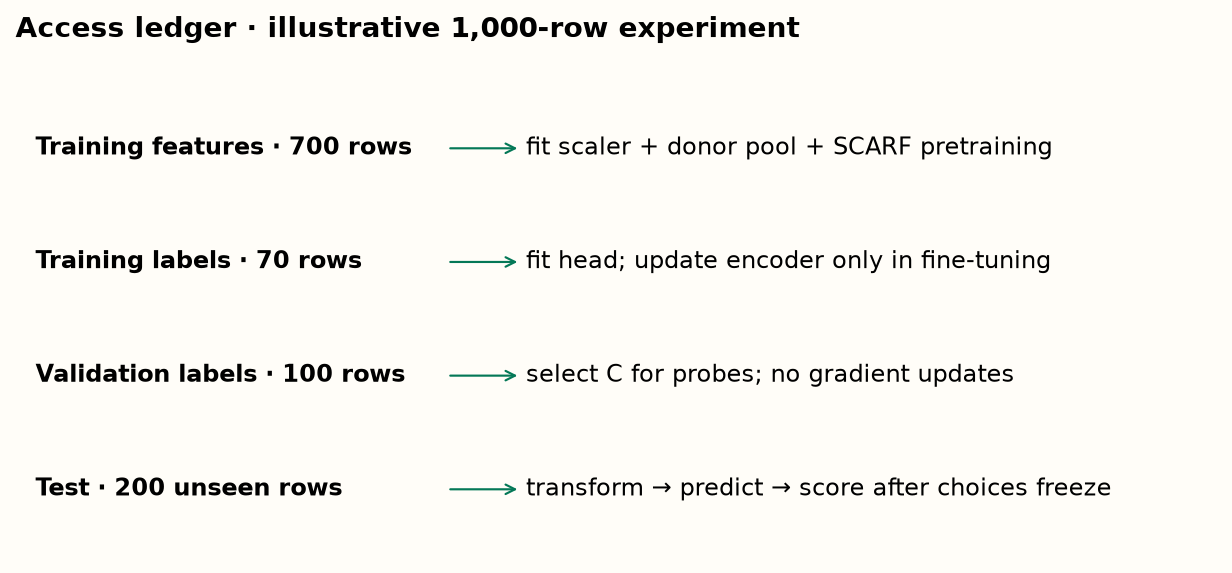</div><figcaption>Illustrative access ledger at 10% labels. Trace which rows can affect fitted parameters before test scoring. On narrow screens, scroll horizontally.</figcaption></figure>

The feature scaler learns means and variances from the entire training pool. SCARF donors and pretraining batches come from that pool too. No validation or test feature contributes to a fitted transformation. A frozen probe fits a second scaler using only its labeled training representations. Its regularization strength is selected from C = 0.1, 1, 10 by validation accuracy, with the first candidate winning a tie. All other recipes have fixed hyperparameters and epoch counts.

**Subtle boundary.** All recipes receive the same train-pool feature scaling, including the scratch baseline. Therefore the primary difference isolates SCARF pretraining on top of shared preprocessing. It does not compare access to all unlabeled information versus access to none.

The benchmark's outer splits are stratified: class proportions guide assignment, using existing benchmark labels. Within the training split, label acquisition is blind to the label values. We assume the list of possible classes is known. This is an offline benchmark simulation, not a claim that a deployed annotation system knows hidden labels.



## 3 · Make the label budgets nested and count them honestly

A **label fraction** f is the fraction of training-pool rows whose target is available to the supervised learner. Our grid is 10%, 20%, 40%, 70%, 100%. The training feature pool stays fixed as f changes. At 100%, self-supervision still adds an objective, even though it adds no extra training rows beyond those with labels.

A **nested subset** preserves every row from the smaller budget. Shuffle training IDs once without reading their labels; take successively longer prefixes. Independently sampling each budget would mix the effect of more labels with replacing the labeled examples. Nesting reduces this avoidable variation; it does not make adjacent budgets independent.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable nesting figure">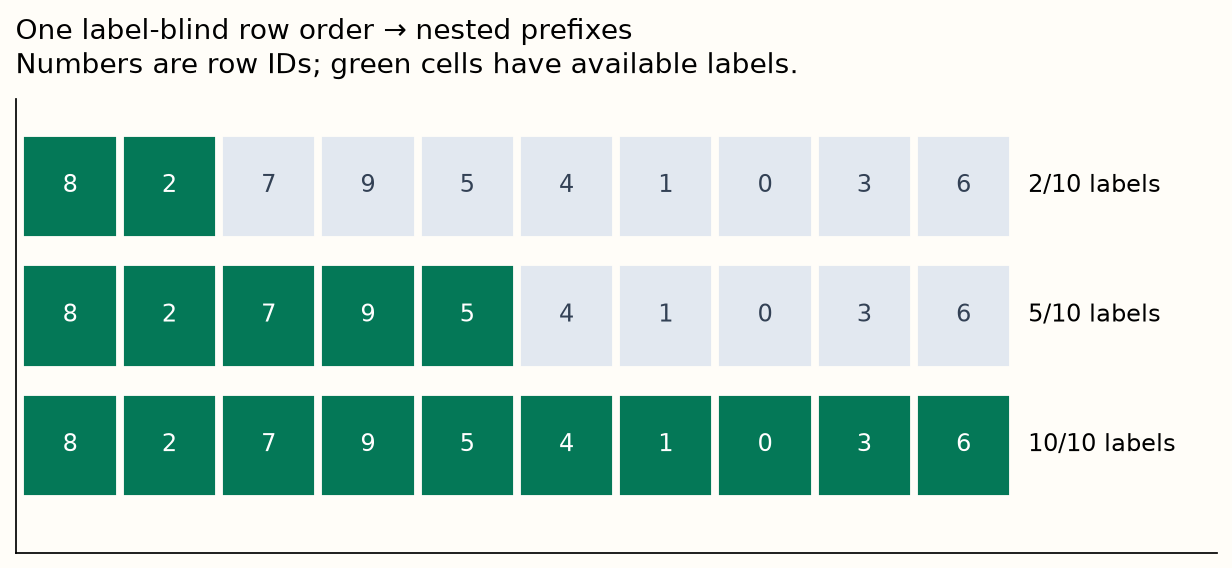</div><figcaption>Illustrative IDs: the same permutation yields 2, 5 and 10 labeled rows. Larger budgets retain every earlier labeled row. On narrow screens, scroll horizontally.</figcaption></figure>

**Worked example.** There are 700 training rows, 100 validation rows and 200 test rows. At f = 0.1, the learner uses 70 training labels. Model development has access to 70 + 100 = 170 labels. That is 21.25% of the 800 development rows, not 10%. The 200 test labels are evaluation annotations and must be accounted for separately if collecting this dataset costs money.

The training count is floor(f × training rows). Flooring means actual fractions can differ slightly from nominal ones. A very small blind sample can omit a class. The lab does not search seeds to repair an inconvenient sample; a one-class logistic training set raises an explicit error. Missing classes should be reported as part of the regime, or addressed by an annotation policy defined before evaluation.

**Recalculate on paper:** if validation labels remain fixed, does halving f halve the total development-label cost? Keep the original 10% case as your reference.



[Oliver et al., §4.6 and §5](https://arxiv.org/html/1804.09170v2) examine validation-set realism and matched baselines in semi-supervised evaluation. Their image experiments motivate this audit; they do not establish a numerical tabular crossover. Here all arms have the same available validation budget, although fixed recipes do not use it to select parameters. We report available labels rather than pretending every method consumed them in the same way.



## 4 · Subtract within a seed before averaging

> **In plain terms.** Compare two runners on the same course before averaging their finishing times.

A **paired repetition** uses the same outer split, labeled subset and relevant random initialization in both arms. Our seed controls a split and model initialization together. Three repetitions therefore mix split and training variation; they do not separate those sources of uncertainty.

**Worked example.** At one budget, treatment accuracy is [0.80, 0.72, 0.90] and control accuracy is [0.75, 0.74, 0.86], ordered by the same seed IDs. Pairwise differences are [+0.05, −0.02, +0.04]. Their mean is +0.0233, or +2.33 **percentage points**. This is not a 2.33% relative improvement.

Accuracy A is the proportion of test rows classified correctly. For repetition s, define g(s,f) = A(treatment,s,f) − A(control,s,f). The mean gain is the sum of the S paired gains divided by S. Join results by seed ID; their storage order can differ.

**Uncertainty.** The sample standard deviation describes the spread of repetition results. The displayed paired t interval is mean gain ± t(0.975,S−1) × SD(g)/sqrt(S). With three gains in the worked example, SD is about 0.0379 and the interval is about [−7.07, +11.74] percentage points. A positive average can coexist with large uncertainty.

> **Scope check.** Our t intervals are descriptive sensitivity summaries over three repetitions of overlapping finite datasets. They do not provide independent-dataset evidence, account for all test-sampling uncertainty, or give simultaneous 95% coverage over the five budgets. More seeds cannot replace more independent datasets.



## 5 · A crossover is a result, not a required ending

A **crossover bracket** here means adjacent tested fractions with strictly opposite mean-gain signs. This operational definition reports where the sampled recipe ordering reverses. It does not estimate an exact threshold between fractions.

**Worked example.** Gains [+3, +1, −2, −1, −3] percentage points at fractions [0.1, 0.2, 0.4, 0.7, 1.0] give a bracket [0.2, 0.4]. The reverse transition is also a sign reversal. A curve may have several; return all of them. Exact zeros are observed ties and are reported separately. All-positive or all-negative means contain no strict adjacent crossing. That does not prove the underlying population curves never cross.

Do not smooth a curve until it tells the preferred story. Do not use a test-derived crossing to choose your deployment method and then claim that same test as independent confirmation. Freeze the follow-up choice and evaluate it on fresh data or within an outer evaluation protocol.





## 6 · Run the fixed experiment and read what happened

**Held fixed:** train feature pool, split IDs, nested label order, architecture within each matched comparison, 40 SCARF pretraining epochs, 60 supervised epochs, Adam learning rate 0.001, batch size 64, corruption rate 0.6 and temperature 1. The compact encoder is d → 64 → 64 with ReLU; the pretraining projector is 64 → 64 → 32. At fine-tuning it is replaced by a 64 → number-of-classes linear head.

**Varied:** the label fraction and six prediction recipes. **Measured:** test accuracy, paired gains, training label counts, validation availability and strict mean-sign reversal brackets. Each dataset/seed pretrains once; each budget receives a fresh copy of that checkpoint. Fine-tuning at 40% never starts from the model trained at 20%.

The three Tier-A offline datasets are sklearn's Wine, Breast Cancer Wisconsin Diagnostic and handwritten Digits. Digits is flattened image data, included to test a contrasting geometry; it is not evidence about ordinary business tables. Five budgets × six arms × three seeds × three datasets produce 270 selected test evaluations. Three probe arms each try three C values using validation only. Fixed neural and tree recipes have no validation search.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable curves figure">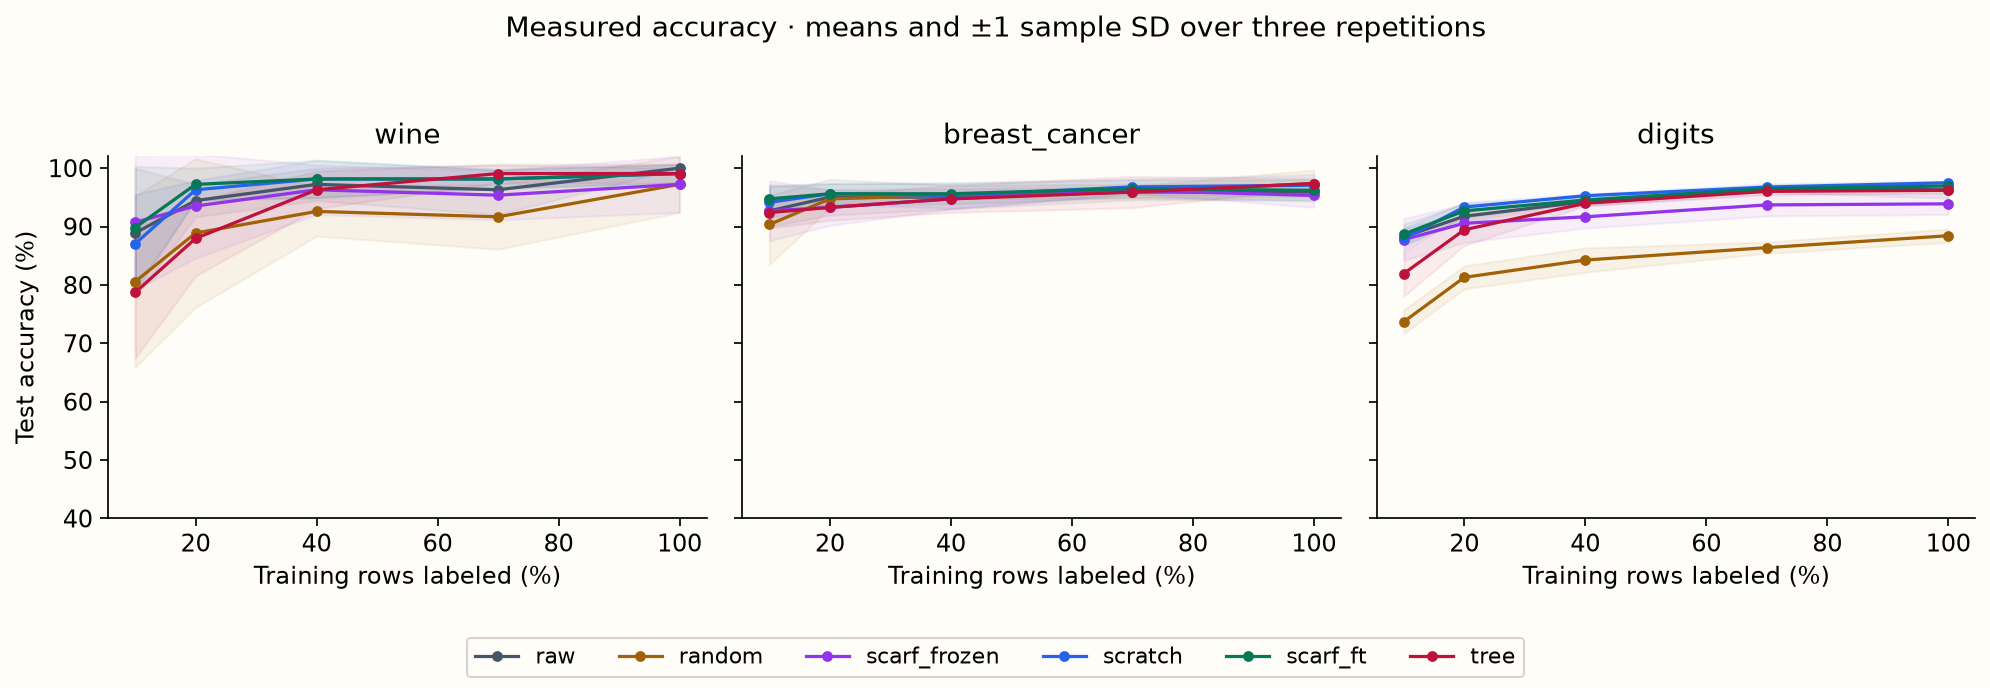</div><figcaption>Author measurements. Curves are means; faint ribbons show sample SD over three paired split/model repetitions. All six recipes receive the same available label budget. On narrow screens, scroll horizontally.</figcaption></figure>

**Author-reference primary gains: SCARF fine-tuned minus scratch, percentage points.** These are saved measurements, not your current kernel output.

| Dataset | 10% | 20% | 40% | 70% | 100% |
|---|---|---|---|---|---|
| wine | +2.78 | +0.93 | +0.00 | +0.00 | +0.00 |
| breast_cancer | +0.58 | +0.00 | +0.29 | -0.29 | -0.88 |
| digits | +0.74 | -0.65 | -0.74 | -0.28 | -0.56 |

**Observed strict adjacent primary brackets:** breast_cancer: [[0.4, 0.7]], ties [0.2]; digits: [[0.1, 0.2]], ties []; wine: none, ties [0.4, 0.7, 1.0].

Neither these brackets nor their direction establishes a population threshold. Inspect the bars and individual gains below.


<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable gains figure">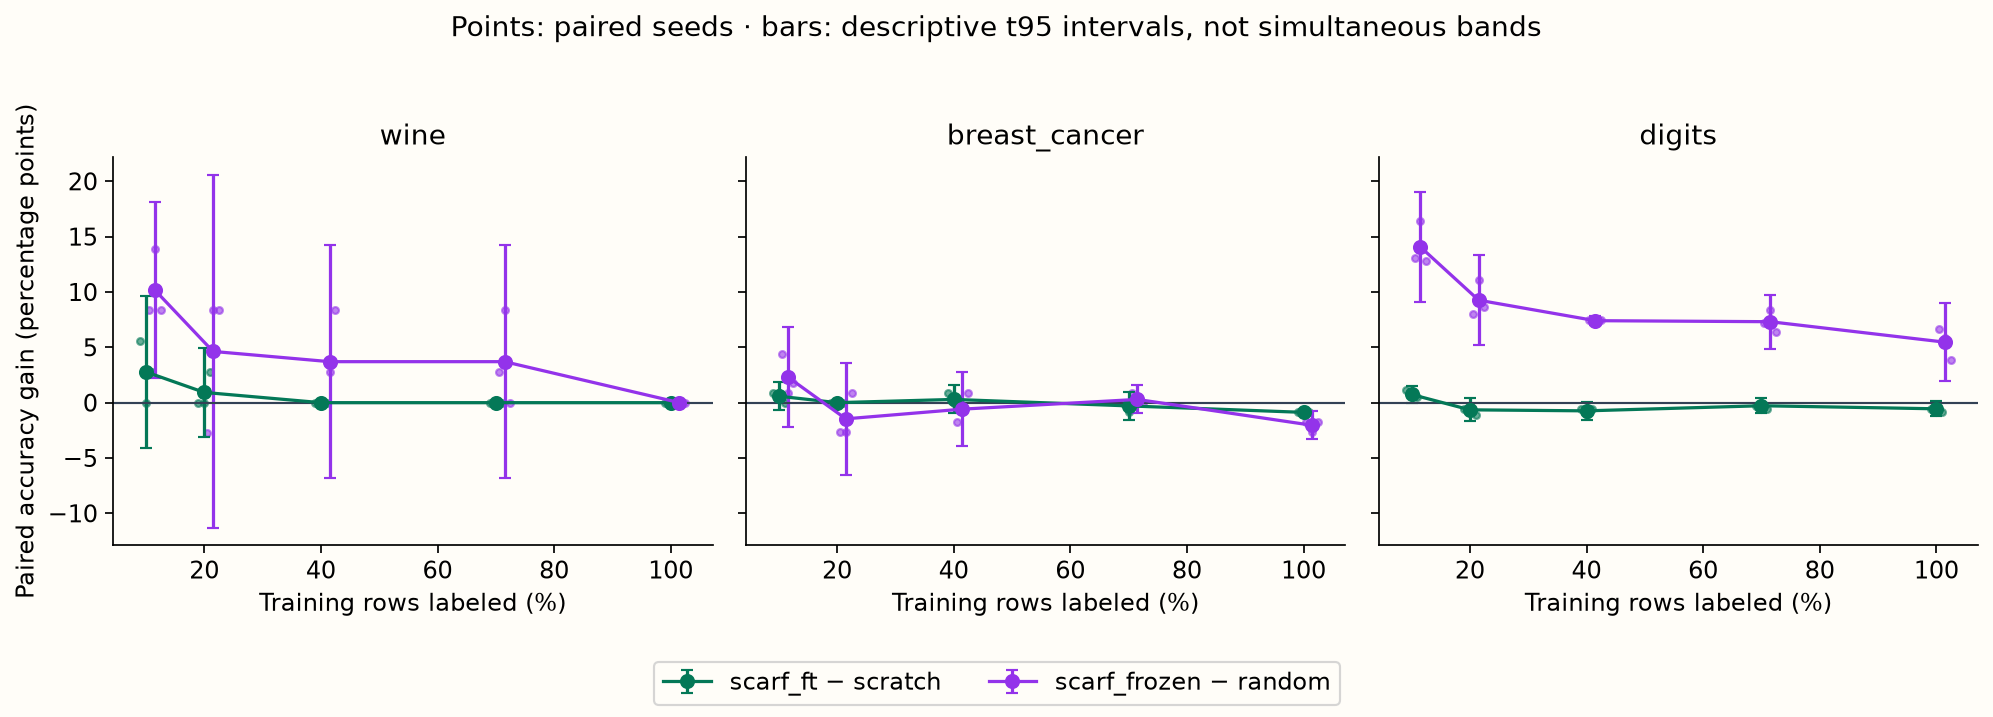</div><figcaption>Author measurements. Small points are individual paired gains; bars are descriptive paired t95 intervals over three repetitions. They are neither simultaneous bands nor independent-dataset uncertainty. On narrow screens, scroll horizontally.</figcaption></figure>

**Observed pattern.** On Digits, frozen SCARF beats random features at every measured budget, yet fine-tuned SCARF has a negative mean gain over scratch from 20% onward. On Wine, the primary comparison ties at 40%, 70% and 100%. On Breast Cancer, the 40–70% bracket is built from mean differences smaller than one percentage point. These patterns make the choice of control and test-set resolution central to the conclusion.

A zero-width interval can occur when all three paired gains happen to be identical. It reports zero observed repetition spread, not certainty about new samples.

**Read in order.** First inspect the primary matched neural comparison. Next ask whether the frozen representation comparison agrees. Finally inspect raw logistic and trees before recommending a recipe. A disagreement between probe and fine-tuning results is a diagnosis target, not an arithmetic contradiction: supervised updates can change what information the encoder preserves.

<figure><div class="figure-scroll" tabindex="0" role="region" aria-label="Scrollable ranks figure">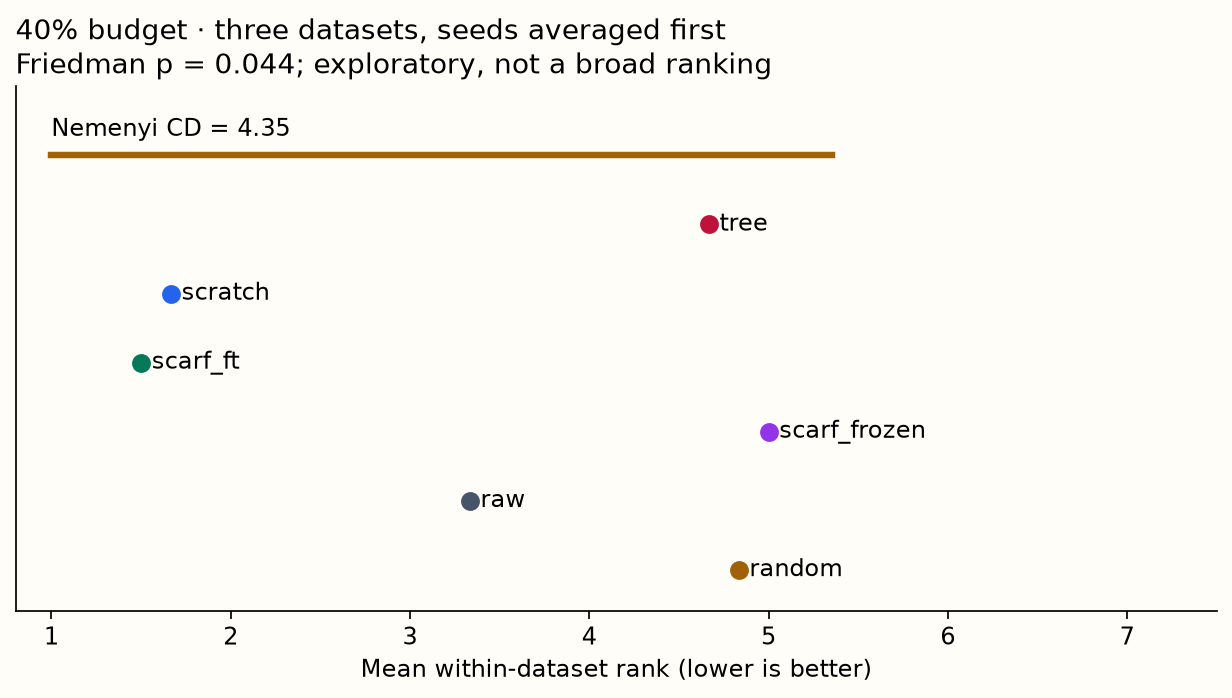</div><figcaption>Author rank audit at 40% labels. Average seeds before ranking datasets equally. The critical difference is exploratory; only three selected datasets are represented. On narrow screens, scroll horizontally.</figcaption></figure>

The rank audit averages seeds within dataset, ranks the six methods within each dataset, and then weights the three datasets equally. Lower rank is better. The Friedman test and Nemenyi critical difference are exploratory summaries at each fraction. Five related rank tests and only three datasets do not justify a universal method ordering. Neither fractions nor seeds count as extra datasets.

> **Scope check.** These are author measurements of a fixed compact protocol. They are INCOMPARABLE to the SCARF benchmark's 69 datasets, 30 trials and training/selection recipe. The paper evaluates 25% and 100% labeled conditions; our denser grid is a teaching experiment, not a reconstructed paper figure. A longer run improves convergence evidence without fixing the dataset and protocol mismatch.



## 7 · Diagnose before adding another experiment

| Observation | Plausible explanation | Follow-up that separates explanations |
|---|---|---|
| Frozen SCARF improves, fine-tuning does not | Supervised optimization erases or cannot exploit its advantage | Log paired validation trajectories; predefine a learning-rate grid |
| Both neural arms lose to raw logistic | The compact encoding or optimizer harms useful coordinates | Compare representation information and longer fixed training |
| Benefit appears only at low f | A learned representation reduces the burden on scarce labels | Repeat with a separately sampled evaluation dataset |
| More pretraining data fails to help | Extra rows carry irrelevant structure or distribution mismatch | Hold labels fixed and vary only eligible unlabeled rows |
| A single seed determines a crossing | Split or optimization sensitivity | Report per-seed gains and run predefined additional seeds |

These are hypotheses, not findings of causal mechanisms. In particular this lab does not vary unlabeled pool size, distribution shift, corruption rate or total compute. Changing them all together would make an explanation harder. Return to your VIME notes: propose a VIME arm with the same boundary and label budget, and state whether it tests an objective or an entire recipe.



## 8 · Lab and exit ticket

Implement three live functions: nested label selection, seed-keyed paired gains, and all strict adjacent crossover brackets. Each has an independent arithmetic CHECK. Read the provided model and training code, then run the full experiment. Your functions must feed that execution; the notebook checks their bindings.

**Before running**, predict the direction of the primary gain at both ends of the grid for each dataset. **After running**, submit your actual curve, counts, paired gains and crossover report. In 150–250 words explain one failed prediction, distinguish a sign reversal from an established threshold, and design one follow-up with exactly one changed factor. Include a practical baseline and the validation-label cost.

Structural EXIT checks verify the row boundary, nested subsets and saved prediction scores. Your written explanation still needs tutor review. Ask the tutor about any unclear step; bring the result and your reasoning, not just “the cell passed.”

**Spaced follow-up:** tomorrow, reconstruct the six comparisons without opening this page. In a week, audit an SSL result from a paper for validation-label cost and baseline matching.

**Mission connection.** Before attributing a future gain to relational structure, match supervision and feature access. This experiment raises the evidential bar; it provides no direct evidence that relational models outperform single-table models. Lesson 74 moves to cross-table transfer, where source-table identity and schema access introduce additional boundaries.

**Primary reading:** [SCARF, Figure 1, §4 and Appendix B](https://arxiv.org/html/2106.15147v2). Read alongside [the tabular SSL survey](https://arxiv.org/html/2402.01204v3) and [Oliver et al.'s evaluation recommendations](https://arxiv.org/html/1804.09170v2). Reproduce their questions about evidence before borrowing their conclusions.



## Paper reproduction track

The [paper reproduction section](../labs/html/0073-when-ssl-helps.html#paper-reproduction) in the companion notebook includes the full runnable paper/release implementation after EXIT, separately from its compact teaching experiment. Read the [reproduction guide](../labs/reproductions/README.md) for the named target, full-data commands, source pins and remaining gaps. The full model and training code are visible in the notebook. Smoke execution and source equivalence are checks; published-result reproduction requires the aligned experiment and its measured comparison.


<a id="lab-exercises"></a>
## Implement the experimental design

PROVIDED cells expose all model and training code. The printed author tables above are reference evidence; your run below generates its own results.

In [ ]:
import copy
import hashlib
import platform
import time
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_wine, load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import t, rankdata, friedmanchisquare, studentized_range
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
torch.set_num_threads(1)

### TODO · nested_labels

Return floor(f*n) prefixes of one seeded label-blind permutation for increasing fractions. Reject invalid fractions and duplicate IDs. Never read labels.

Predict the arithmetic fixture before running CHECK. Explain which bias a careless implementation would introduce.

In [ ]:
def nested_labels(train, fractions, seed):
    raise NotImplementedError("nested_labels")

In [ ]:
# CHECK
g=nested_labels(list(range(20)),[.1,.5,1.],73)
assert list(map(len,g))==[2,10,20]
assert set(g[0])<set(g[1])<set(g[2])
assert g==nested_labels(list(range(20)),[.1,.5,1.],73)
print("nested_labels: passed")

### TODO · paired_gains

For one dataset/fraction, join treatment and control by seed, sort seeds, and return accuracy differences. Reject missing and duplicate pairs.

Predict the arithmetic fixture before running CHECK. Explain which bias a careless implementation would introduce.

In [ ]:
def paired_gains(rows, treatment, control):
    raise NotImplementedError("paired_gains")

In [ ]:
# CHECK
rr=[{'seed':2,'arm':'ssl','accuracy':.9},{'seed':1,'arm':'base','accuracy':.7},{'seed':1,'arm':'ssl','accuracy':.6},{'seed':2,'arm':'base','accuracy':.6}]
assert np.allclose(paired_gains(rr,'ssl','base'),[-.1,.3])
for bad in [rr[:-1],rr+[rr[0]]]:
    try:paired_gains(bad,'ssl','base')
    except ValueError:pass
    else:raise AssertionError('Reject incomplete or duplicated seed pairs')
print("paired_gains: passed")

### TODO · crossing_brackets

Return every adjacent fraction pair whose gains have strictly opposite signs. Check lengths, increasing fractions and finite gains. Keep exact ties out.

Predict the arithmetic fixture before running CHECK. Explain which bias a careless implementation would introduce.

In [ ]:
def crossing_brackets(fractions, gains):
    raise NotImplementedError("crossing_brackets")

In [ ]:
# CHECK
assert crossing_brackets([.1,.2,.4,1.],[.02,-.01,.03,-.01])==[[.1,.2],[.2,.4],[.4,1.]]
assert crossing_brackets([.1,.2,1.],[.02,0.,-.01])==[]
assert crossing_brackets([.1,.2,1.],[.02,.01,.01])==[]
print("crossing_brackets: passed")

### PROVIDED · SCARF carried forward from Lesson 72: follow the donor columns, N-way loss and encoder/projector boundary

In [ ]:
def corrupt(x, bank, mask, donors):
    """Independent donor row per cell; each value stays in its original column."""
    columns = torch.arange(x.shape[1], device=x.device)[None, :]
    return torch.where(mask, bank[donors, columns], x)

In [ ]:
def scarf_loss(clean, changed, tau=1.):
    """N clean anchors × N corrupt candidates; CE differs from paper by +log(N)."""
    if tau <= 0 or len(clean) < 2:
        raise ValueError('Positive temperature and at least two rows required')
    scores = F.normalize(clean, dim=1) @ F.normalize(changed, dim=1).T / tau
    return F.cross_entropy(scores, torch.arange(len(clean), device=clean.device))

In [ ]:
def draw_view(x, bank, rate=.6):
    q = int(rate * x.shape[1])
    mask = torch.zeros_like(x, dtype=torch.bool)
    chosen = torch.rand_like(x).argsort(dim=1)[:, :q]
    mask.scatter_(1, chosen, True)
    donors = torch.randint(len(bank), x.shape, device=x.device)
    return corrupt(x, bank, mask, donors)

In [ ]:
class SCARF(nn.Module):
    """Local compact f: d->64->64; g: 64->64->32; ReLU after hidden layers."""
    def __init__(self, d, width=64):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d,width),nn.ReLU(),nn.Linear(width,width),nn.ReLU())
        self.projector = nn.Sequential(nn.Linear(width,width),nn.ReLU(),nn.Linear(width,32))
    def forward(self, x):
        return self.projector(self.encoder(x))
    def represent(self, x):
        return self.encoder(x)

### PROVIDED · Feature access and paired initialization: identify every fit-row set

In [ ]:
def load_regime(name, seed):
    data={'wine':load_wine,'breast_cancer':load_breast_cancer,'digits':load_digits}[name]()
    raw=data.data.astype('float32');y=data.target
    tr,held=train_test_split(np.arange(len(y)),test_size=.3,stratify=y,random_state=seed)
    va,te=train_test_split(held,test_size=2/3,stratify=y[held],random_state=seed)
    scale=StandardScaler().fit(raw[tr])
    return scale.transform(raw).astype('float32'),y,len(data.target_names),{
        'train':tr.tolist(),'validation':va.tolist(),'test':te.tolist(),
        'feature_mean':scale.mean_.tolist(),'data_sha256':hashlib.sha256(raw.tobytes()+y.tobytes()).hexdigest()}

In [ ]:
def initialize(x, seed, epochs=40):
    """Create paired random and pretrained encoders using only training features."""
    torch.manual_seed(seed);random=SCARF(x.shape[1]);net=copy.deepcopy(random)
    opt=torch.optim.Adam(net.parameters(),lr=.001);x=torch.tensor(x);history=[]
    for epoch in range(epochs):
        losses=[]
        for ix in torch.randperm(len(x)).split(64):
            if len(ix)<2:continue
            b=x[ix];loss=scarf_loss(net(b),net(draw_view(b,x,.6)))
            opt.zero_grad();loss.backward();opt.step();losses.append(float(loss.detach()))
        history.append(float(np.mean(losses)))
    return random.eval(),net.eval(),history

### PROVIDED · Frozen versus trainable encoders: find the reset and the validation-only selection

In [ ]:
def predict_probe(features, y, ids):
    tr,va,te=[ids[k] for k in ['labeled','validation','test']]
    if len(np.unique(y[tr]))<2:raise ValueError('Label-blind budget has one class; report failure, do not resample')
    scale=StandardScaler().fit(features[tr]);f=scale.transform(features)
    trials=[];best=None
    for c in [.1,1.,10.]:
        model=LogisticRegression(C=c,max_iter=2000).fit(f[tr],y[tr])
        score=float(np.mean(model.predict(f[va])==y[va]));trials.append({'C':c,'validation_accuracy':score})
        if best is None or score>best[0]:best=(score,model,c)
    return best[1].predict(f[te]),{'trials':trials,'selected_C':best[2]}

In [ ]:
def predict_tuned(net, x, y, ids, classes, seed, epochs=60):
    """Same head initialization, batches and steps in scratch/pretrained arms."""
    torch.manual_seed(seed+1000)
    encoder=copy.deepcopy(net.encoder)
    model=nn.Sequential(encoder,nn.Linear(64,classes))
    opt=torch.optim.Adam(model.parameters(),lr=.001)
    tr=ids['labeled'];xt=torch.tensor(x[tr]);yt=torch.tensor(y[tr],dtype=torch.long)
    initial=copy.deepcopy(encoder.state_dict())
    model.train()
    for epoch in range(epochs):
        for ix in torch.randperm(len(tr)).split(64):
            loss=F.cross_entropy(model(xt[ix]),yt[ix]);opt.zero_grad();loss.backward();opt.step()
    model.eval()
    with torch.no_grad():pred=model(torch.tensor(x[ids['test']])).argmax(1).numpy()
    delta=sum(float((encoder.state_dict()[k]-v).abs().sum()) for k,v in initial.items())
    return pred,{'encoder_delta':delta,'supervised_epochs':epochs}

### PROVIDED · The runner: find the nested subsets, seed join and crossing functions you implemented

In [ ]:
def summarize_regimes(records, fractions):
    summaries=[];contrasts=[];crossings=[];rank_audits=[]
    datasets=sorted({r['dataset'] for r in records});arms=sorted({r['arm'] for r in records})
    for d in datasets:
        for f in fractions:
            rows=[r for r in records if r['dataset']==d and r['fraction']==f]
            for a in arms:
                values=[r['accuracy'] for r in rows if r['arm']==a]
                summaries.append({'dataset':d,'fraction':f,'arm':a,'mean':float(np.mean(values)),
                                  'sd':float(np.std(values,ddof=1)),'seed_values':values})
            for treatment,control in [('scarf_ft','scratch'),('scarf_frozen','random'),('scarf_ft','raw'),('scarf_ft','tree')]:
                g=np.array(paired_gains(rows,treatment,control));mean=float(g.mean())
                radius=float(t.ppf(.975,len(g)-1)*g.std(ddof=1)/np.sqrt(len(g)))
                contrasts.append({'dataset':d,'fraction':f,'treatment':treatment,'control':control,
                                  'gains':g.tolist(),'mean':mean,'interval':[mean-radius,mean+radius]})
        for treatment,control in [('scarf_ft','scratch'),('scarf_frozen','random')]:
            gains=[next(c['mean'] for c in contrasts if c['dataset']==d and c['fraction']==f and c['treatment']==treatment and c['control']==control) for f in fractions]
            crossings.append({'dataset':d,'comparison':treatment+' - '+control,'brackets':crossing_brackets(fractions,gains),
                              'ties':[f for f,g in zip(fractions,gains) if g==0]})
    for f in fractions:
        scores=np.array([[next(s['mean'] for s in summaries if s['dataset']==d and s['fraction']==f and s['arm']==a) for a in arms] for d in datasets])
        k=len(arms);n=len(datasets);ranks=np.array([rankdata(-row) for row in scores])
        rank_audits.append({'fraction':f,'arms':arms,'mean_ranks':ranks.mean(0).tolist(),
            'friedman_p':float(friedmanchisquare(*scores.T).pvalue) if n>=3 else None,
            'cd':float(studentized_range.ppf(.95,k,np.inf)/np.sqrt(2)*np.sqrt(k*(k+1)/(6*n)))})
    return summaries,contrasts,crossings,rank_audits

In [ ]:
def run_regimes(datasets=('wine','breast_cancer','digits'), seeds=(0,1,2), fractions=(.1,.2,.4,.7,1.), pre_epochs=40, fine_epochs=60):
    started=time.time();torch.set_num_threads(1);records=[];splits=[];traces=[]
    for d in datasets:
        for seed in seeds:
            x,y,k,s=load_regime(d,seed);groups=nested_labels(s['train'],fractions,seed+73)
            splits.append({'dataset':d,'seed':seed,**s,'labeled_groups':groups})
            random,ssl,history=initialize(x[s['train']],seed,pre_epochs)
            traces.append({'dataset':d,'seed':seed,'loss':history})
            with torch.no_grad():
                features={'raw':x,'random':random.represent(torch.tensor(x)).numpy(),
                          'scarf_frozen':ssl.represent(torch.tensor(x)).numpy()}
            for f,labels in zip(fractions,groups):
                ids={**s,'labeled':labels}
                for arm in ['raw','random','scarf_frozen','scratch','scarf_ft','tree']:
                    if arm in features:pred,extra=predict_probe(features[arm],y,ids)
                    elif arm=='tree':
                        model=HistGradientBoostingClassifier(max_iter=100,max_leaf_nodes=15,min_samples_leaf=5,l2_regularization=1.,early_stopping=False,random_state=seed).fit(x[labels],y[labels])
                        pred=model.predict(x[s['test']]);extra={'iterations':100}
                    else:pred,extra=predict_tuned(random if arm=='scratch' else ssl,x,y,ids,k,seed,fine_epochs)
                    records.append({'dataset':d,'seed':seed,'fraction':f,'arm':arm,
                        'accuracy':float(np.mean(pred==y[s['test']])),'prediction':pred.tolist(),'target':y[s['test']].tolist(),
                        'train_labels':len(labels),'validation_labels':len(s['validation']),'total_development_labels':len(labels)+len(s['validation']),**extra})
            print(d,seed,'completed',flush=True)
    summary,contrasts,crossings,ranks=summarize_regimes(records,fractions)
    return {'config':{'datasets':list(datasets),'seeds':list(seeds),'fractions':list(fractions),'pre_epochs':pre_epochs,'fine_epochs':fine_epochs,'batch':64,'lr':.001,'corruption':.6,'tau':1.},
        'environment':{'python':platform.python_version(),'torch':torch.__version__,'numpy':np.__version__,'sklearn':sklearn_version},
        'elapsed_seconds':time.time()-started,'records':records,'splits':splits,'traces':traces,
        'summary':summary,'contrasts':contrasts,'crossings':crossings,'rank_audits':ranks,
        'interval_scope':'Descriptive paired t95 intervals over three overlapping split/model repetitions; no independent-dataset or simultaneous coverage claim.',
        'verdict':'INCOMPARABLE to original paper benchmarks; fixed local label-budget experiment.'}

### RUN · commit predictions first

Write the sign of the primary gain at 10% and 100% for each dataset. Then run. The experiment typically takes a few CPU minutes; runtime depends on hardware.

In [ ]:
assert run_regimes.__globals__['nested_labels'] is nested_labels
assert summarize_regimes.__globals__['paired_gains'] is paired_gains
assert summarize_regimes.__globals__['crossing_brackets'] is crossing_brackets
result=run_regimes()
Path('l073-student-results.json').write_text(json.dumps(result,indent=2))
display(pd.DataFrame(result['summary'])[['dataset','fraction','arm','mean','sd']])
display(pd.DataFrame(result['crossings']))

In [ ]:
# Plot YOUR fresh paired gains
fig,axes=plt.subplots(1,3,figsize=(13,4),sharey=True)
for ax,d in zip(axes,result['config']['datasets']):
    ss=[c for c in result['contrasts'] if c['dataset']==d and c['treatment']=='scarf_ft' and c['control']=='scratch']
    for c in ss:
        ax.scatter([100*c['fraction']]*len(c['gains']),100*np.array(c['gains']),s=18)
    ax.plot([100*c['fraction'] for c in ss],[100*c['mean'] for c in ss],'k.-')
    ax.axhline(0,color='gray');ax.set(title=d,xlabel='Training labels (%)')
axes[0].set_ylabel('SCARF FT − scratch (percentage points)')
plt.tight_layout();plt.show()

### EXIT · measurements plus argument

Submit your curves, paired gains, label counts, ties and brackets. Explain one failed prediction in 150–250 words; include a practical comparator, interval limits, validation-label cost and one controlled follow-up. No crossing is an acceptable finding.

In [ ]:
assert len(result['records'])==270
for s in result['splits']:
    tr,va,te=map(set,[s['train'],s['validation'],s['test']])
    assert not tr&va and not tr&te and not va&te
    previous=set()
    for g in s['labeled_groups']:
        assert previous<=set(g)<=tr
        previous=set(g)
for r in result['records']:
    assert abs(np.mean(np.array(r['prediction'])==r['target'])-r['accuracy'])<1e-12
    assert r['total_development_labels']==r['train_labels']+r['validation_labels']
    if r['arm'] in ['scratch','scarf_ft']:assert r['encoder_delta']>0
print('Structural EXIT passed. Written explanation needs tutor review.')

**Write your interpretation here.** Tomorrow, reconstruct the evaluation boundary from memory.

### Optional teaching extension · predeclared convergence audit

Hold datasets, budgets and method choices fixed; run five seeds with 200 pretraining and supervised epochs using your live functions. This changes the optimization budget and repetition count, not benchmark fidelity. Use fresh evaluation data before turning a test-derived crossover into a deployment decision. The larger run is gated off by default.

In [ ]:
RUN_LONGER=False
if RUN_LONGER:
    longer=run_regimes(seeds=tuple(range(5)),pre_epochs=200,fine_epochs=200)
    Path('l073-longer-results.json').write_text(json.dumps(longer,indent=2))
else:
    print('Longer run NOT_RUN; original paper benchmarks INCOMPARABLE; live Colab NOT_CHECKED.')

<a id="paper-reproduction"></a>
## Paper reproduction · implementation, protocol, and measured comparison

**Target:** SCARF Table 2 (100% labeled training) versus Table 4 (25% labeled training), using the same full implementation as Lesson 72. Validation and test proportions stay fixed at 10% and 20%; only the training-label fraction changes. Record 30 paired splits and compare both control and SCARF with the published per-dataset means.

The lesson's five-budget crossover experiment is an extension. It is distinct from these two published regimes. No new model or invented survey experiment is needed for this evaluation lesson.

**Read → predict → run.** Compare each architecture and stopping rule below with the teaching lane. Predict which protocol changes could reverse its ranking. The following PROVIDED cells write the visible source to an isolated `paper-run` folder. The runner imports those exact files, so edits in these cells are the implementation it trains. Run all source cells before enabling the final run. After editing a source chunk, rerun that file’s source cells from the first chunk so append cells do not duplicate definitions. Preserve the pinned copy for parity checks.

**Evidence rule:** a smoke run tests execution and is always INCOMPARABLE. A full run records published targets, measured gaps, source choices and missing details; a small score gap alone does not certify protocol identity. [Reproduction guide](../labs/reproductions/README.md).

In [ ]:
# PROVIDED: isolated files for the visible paper implementation
from pathlib import Path
import sys, subprocess
PAPER_ROOT=Path('paper-run').resolve()
PAPER_ROOT.mkdir(exist_ok=True)

### PROVIDED · scarf.py

Trace original-column corruption → f/g pretraining → validation checkpoint → new h → joint f/h fine-tuning. The full data split and comparison loop are visible here.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/scarf.py
"""SCARF paper Tables 2 and 4: complete visible implementation, no packaged model.

Source: https://arxiv.org/html/2106.15147v2, Algorithm 1 and Section 4.
Unspecified choices (seed list, split stratification, initialization, scaling population)
are recorded as reconstruction choices, never claimed as author-code parity.
"""
import copy
import hashlib
import json
import math
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split




#### paper_config

In [ ]:
%%writefile -a paper-run/scarf.py
def paper_config():
    return dict(width=256,pre_epochs=1000,epochs=200,patience=3,batch=128,
                lr=.001,corruption=.6,tau=1.,validation_passes=10,seeds=list(range(30)))




#### ScarfEncoder

In [ ]:
%%writefile -a paper-run/scarf.py
class ScarfEncoder(nn.Sequential):
    """f: four affine/ReLU layers, including a ReLU on the representation."""
    def __init__(self,d):
        super().__init__(nn.Linear(d,256),nn.ReLU(),*[m for _ in range(3)
                         for m in (nn.Linear(256,256),nn.ReLU())])




#### ScarfProjection

In [ ]:
%%writefile -a paper-run/scarf.py
class ScarfProjection(nn.Sequential):
    """g: two-layer ReLU head; the loss normalizes its output."""
    def __init__(self):
        super().__init__(nn.Linear(256,256),nn.ReLU(),nn.Linear(256,256),nn.ReLU())




#### scarf_objective

In [ ]:
%%writefile -a paper-run/scarf.py
def scarf_objective(a,b,tau=1.):
    scores=F.normalize(a,dim=1)@F.normalize(b,dim=1).T/tau
    # Paper denominator is the MEAN of N exponentials, hence the -log(N).
    return F.cross_entropy(scores,torch.arange(len(a),device=a.device))-math.log(len(a))




#### corrupt_columns

In [ ]:
%%writefile -a paper-run/scarf.py
def corrupt_columns(x,bank,groups,rate,generator):
    """Uniformly choose floor(c*M) original columns, then independent marginal donors.

    A categorical block is replaced together; this equals corruption before one-hot
    encoding. Drawing separate donors for one-hot bits would create invalid categories.
    """
    mask=torch.zeros((len(x),len(groups)),dtype=torch.bool)
    count=int(rate*len(groups))
    chosen=torch.rand((len(x),len(groups)),generator=generator).argsort(1)[:,:count]
    mask.scatter_(1,chosen,True)
    donors=torch.randint(len(bank),(len(x),len(groups)),generator=generator)
    changed=x.clone()
    for j,group in enumerate(groups):
        rows=mask[:,j].nonzero().flatten().to(x.device)
        changed[rows,group]=bank[donors[mask[:,j],j].to(bank.device),group]
    return changed,mask




#### load_openml

In [ ]:
%%writefile -a paper-run/scarf.py
def load_openml(data_id,seed):
    """70/10/20 random split; published full-table missing-value imputation.

    Scaling is fit on training rows. The paper does not specify its fitting population.
    Use full-table categories to reproduce the explicitly transductive categorical
    vocabulary/imputation; expose that choice instead of calling this leak-free.
    """
    bunch=fetch_openml(data_id=int(data_id),as_frame=True,parser='auto')
    frame=bunch.data.copy();y=pd.factorize(bunch.target,sort=True)[0].astype('int64')
    ids=np.arange(len(y))
    development,test=train_test_split(ids,test_size=.2,random_state=seed)
    train,valid=train_test_split(development,test_size=.125,random_state=seed)
    blocks=[];groups=[];offset=0;columns=[]
    for name in frame:
        col=frame[name]
        if col.isna().all():continue
        numeric=pd.api.types.is_numeric_dtype(col)
        if numeric:
            values=pd.to_numeric(col).fillna(col.mean()).to_numpy(dtype='float64')
            if int(data_id) not in (4134,28,1468):
                sd=values[train].std();values=(values-values[train].mean())/(sd if sd else 1.)
            block=values[:,None]
        else:
            values=col.astype(object).fillna(col.mode().iloc[0])
            codes,levels=pd.factorize(values,sort=True)
            block=np.eye(len(levels),dtype='float32')[codes]
        groups.append(slice(offset,offset+block.shape[1]));offset+=block.shape[1]
        blocks.append(block);columns.append(str(name))
    X=np.concatenate(blocks,axis=1).astype('float32')
    assert np.isfinite(X).all() and (y>=0).all()
    provenance=dict(openml_id=int(data_id),version=int(bunch.details['version']),
                    rows=len(y),original_columns=columns,encoded_dim=X.shape[1],
                    data_sha256=hashlib.sha256(pd.util.hash_pandas_object(frame,index=True).values.tobytes()+y.tobytes()).hexdigest(),
                    train=train.tolist(),validation=valid.tolist(),test=test.tolist())
    return torch.from_numpy(X),torch.from_numpy(y),groups,train,valid,test,provenance




#### pretrain_scarf

In [ ]:
%%writefile -a paper-run/scarf.py
def pretrain_scarf(x,xv,groups,seed,cfg,device):
    torch.manual_seed(seed);encoder=ScarfEncoder(x.shape[1]).to(device)
    model=nn.Sequential(encoder,ScarfProjection().to(device))
    optimizer=torch.optim.Adam(model.parameters(),lr=cfg['lr'])
    generator=torch.Generator().manual_seed(seed+10000)
    x=x.to(device);xv=xv.to(device)
    # Freeze both candidates and batch membership for ten full validation passes.
    validation=[]
    for _ in range(cfg['validation_passes']):
        for idx in torch.randperm(len(xv),generator=generator).split(cfg['batch']):
            if len(idx)<2:continue
            clean=xv[idx.to(device)]
            changed,_=corrupt_columns(clean,xv,groups,cfg['corruption'],generator)
            validation.append((clean,changed))
    best=float('inf');state=None;wait=0;trace=[]
    for epoch in range(cfg['pre_epochs']):
        model.train();training=[]
        for idx in torch.randperm(len(x),generator=generator).split(cfg['batch']):
            if len(idx)<2:continue
            clean=x[idx.to(device)]
            changed,_=corrupt_columns(clean,x,groups,cfg['corruption'],generator)
            loss=scarf_objective(model(clean),model(changed),cfg['tau'])
            optimizer.zero_grad();loss.backward();optimizer.step();training.append(loss.item())
        model.eval()
        with torch.no_grad():
            value=sum(len(a)*scarf_objective(model(a),model(b),cfg['tau']).item() for a,b in validation)/sum(len(a) for a,b in validation)
        trace.append(dict(epoch=epoch+1,train=float(np.mean(training)),validation=value))
        if value<best:
            best=value;state=copy.deepcopy(encoder.state_dict());wait=0
        else:wait+=1
        if wait>=cfg['patience']:break
    encoder.load_state_dict(state)
    return encoder,trace




#### finetune_scarf

In [ ]:
%%writefile -a paper-run/scarf.py
def finetune_scarf(encoder,x,y,xv,yv,classes,seed,cfg,device):
    """Both f and newly initialized h receive gradients; validate classification error."""
    torch.manual_seed(seed+20000)
    head=nn.Sequential(nn.Linear(256,256),nn.ReLU(),nn.Linear(256,classes))
    model=nn.Sequential(copy.deepcopy(encoder).cpu(),head).to(device)
    before=copy.deepcopy(model[0].state_dict())
    opt=torch.optim.Adam(model.parameters(),lr=cfg['lr'])
    gen=torch.Generator().manual_seed(seed+30000)
    x,y,xv,yv=[v.to(device) for v in (x,y,xv,yv)]
    best=float('inf');state=None;wait=0;trace=[]
    for epoch in range(cfg['epochs']):
        model.train()
        for idx in torch.randperm(len(x),generator=gen).split(cfg['batch']):
            idx=idx.to(device);loss=F.cross_entropy(model(x[idx]),y[idx])
            opt.zero_grad();loss.backward();opt.step()
        model.eval()
        with torch.no_grad():value=float((model(xv).argmax(1)!=yv).float().mean())
        trace.append(dict(epoch=epoch+1,validation_error=value))
        if value<best:
            best=value;state=copy.deepcopy(model.state_dict());wait=0
        else:wait+=1
        if wait>=cfg['patience']:break
    model.load_state_dict(state)
    delta=sum(float((v-before[k]).abs().sum()) for k,v in model[0].state_dict().items())
    return model,dict(trace=trace,encoder_update_l1=delta,validation_error=best)




#### run_scarf

In [ ]:
%%writefile -a paper-run/scarf.py
def run_scarf(data_ids=(37,1464,40975),fractions=(1.,.25),smoke=False,device='cpu',output=None):
    """Default reproduces six named table rows; --all-data selects all 69.

    Smoke alone changes rows/epochs/seeds and is categorically INCOMPARABLE.
    Save after every arm so a long 30-split run retains completed measurements.
    """
    torch.set_num_threads(1);start=time.time();cfg=paper_config()
    if smoke:cfg.update(pre_epochs=2,epochs=3,seeds=[0],validation_passes=2)
    targets=json.loads((Path(__file__).parent/'scarf_targets.json').read_text())
    result=dict(paper='SCARF Tables 2 and 4',config=cfg,records=[],splits=[],smoke=smoke,
                verdict='INCOMPARABLE' if smoke else 'REPLICATION_MEASURED',
                remaining=['Author seeds and code were not released; independent reconstruction.',
                           'Unspecified split stratification, initialization and scaling population use documented choices.',
                           'Pretraining head interpreted as two affine/ReLU layers.',
                           'Selected dataset rows only unless all 69 IDs are requested.'])
    for data_id in data_ids:
        if str(data_id) not in targets['1.0']:raise ValueError('Dataset is not a published SCARF row')
        for seed in cfg['seeds']:
            X,y,groups,tr,va,te,split=load_openml(data_id,seed)
            if smoke:tr=tr[:256];va=va[:64];te=te[:128];split.update(train=tr.tolist(),validation=va.tolist(),test=te.tolist())
            split.update(seed=seed);result['splits'].append(split)
            encoder,pretrace=pretrain_scarf(X[tr],X[va],groups,seed,cfg,device)
            for fraction in fractions:
                if fraction not in (1.,.25):raise ValueError('Paper tables use 100% or 25%; extensions belong in the teaching lane')
                labeled=np.random.RandomState(seed+40000).permutation(tr)[:max(1,int(len(tr)*fraction))]
                for arm in ['control','scarf']:
                    torch.manual_seed(seed);initial=ScarfEncoder(X.shape[1]) if arm=='control' else encoder
                    model,details=finetune_scarf(initial,X[labeled],y[labeled],X[va],y[va],int(y.max())+1,seed,cfg,device)
                    with torch.no_grad():pred=torch.cat([model(batch.to(device)).argmax(1).cpu() for batch in X[te].split(1024)])
                    accuracy=float((pred==y[te]).float().mean())
                    target=targets[str(fraction)][str(data_id)][arm]/100
                    record=dict(data_id=data_id,seed=seed,fraction=fraction,arm=arm,accuracy=accuracy,
                                paper_mean=target,gap_to_paper=accuracy-target,train_labels=len(labeled),
                                validation_labels=len(va),labeled=labeled.tolist(),pretrain_trace=pretrace if arm=='scarf' else [],
                                prediction=pred.tolist(),target=y[te].tolist(),**details)
                    result['records'].append(record);result['seconds']=time.time()-start
                    if output:Path(output).write_text(json.dumps(result,indent=2))
                    print(f'SCARF id={data_id} seed={seed} labels={fraction} {arm} accuracy={accuracy:.4f}',flush=True)
    result['summary']=[]
    for data_id in data_ids:
        for fraction in fractions:
            for arm in ['control','scarf']:
                values=[r['accuracy'] for r in result['records'] if (r['data_id'],r['fraction'],r['arm'])==(data_id,fraction,arm)]
                target=targets[str(fraction)][str(data_id)][arm]/100
                mean=float(np.mean(values))
                result['summary'].append(dict(data_id=data_id,fraction=fraction,arm=arm,n=len(values),mean=mean,
                    sd=float(np.std(values,ddof=1)) if len(values)>1 else None,paper_mean=target,gap=mean-target,
                    comparison='INCOMPARABLE' if smoke else ('WITHIN_1PP' if abs(mean-target)<=.01 else 'OUTSIDE_1PP')))
    if output:Path(output).write_text(json.dumps(result,indent=2))
    return result


if __name__=='__main__':
    import argparse
    parser=argparse.ArgumentParser();parser.add_argument('--smoke',action='store_true')
    parser.add_argument('--all-data',action='store_true');parser.add_argument('--data-ids',default='37,1464,40975')
    parser.add_argument('--device',default='cpu');parser.add_argument('--output',default='scarf-paper-results.json')
    args=parser.parse_args()
    ids=list(map(int,json.loads((Path(__file__).parent/'scarf_targets.json').read_text())['1.0'])) if args.all_data else list(map(int,args.data_ids.split(',')))
    run_scarf(ids,smoke=args.smoke,device=args.device,output=args.output)


In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/scarf_targets.json').write_text('{\n  "1.0": {\n    "6": {\n      "control": 94.69,\n      "scarf": 95.75\n    },\n    "6332": {\n      "control": 74.24,\n      "scarf": 75.4\n    },\n    "54": {\n      "control": 75.45,\n      "scarf": 76.75\n    },\n    "50": {\n      "control": 90.54,\n      "scarf": 97.53\n    },\n    "46": {\n      "control": 93.47,\n      "scarf": 94.59\n    },\n    "469": {\n      "control": 18.54,\n      "scarf": 19.08\n    },\n    "458": {\n      "control": 98.96,\n      "scarf": 99.51\n    },\n    "4538": {\n      "control": 56.28,\n      "scarf": 60.32\n    },\n    "4534": {\n      "control": 96.08,\n      "scarf": 95.85\n    },\n    "44": {\n      "control": 93.4,\n      "scarf": 94.46\n    },\n    "4134": {\n      "control": 75.53,\n      "scarf": 75.51\n    },\n    "41027": {\n      "control": 90.96,\n      "scarf": 91.13\n    },\n    "40994": {\n      "control": 90.97,\n      "scarf": 90.91\n    },\n    "40984": {\n      "control": 90.56,\n      "scarf": 91.97\n    },\n    "40983": {\n      "control": 98.59,\n      "scarf": 98.7\n    },\n    "40982": {\n      "control": 73.48,\n      "scarf": 73.27\n    },\n    "40979": {\n      "control": 96.68,\n      "scarf": 97.45\n    },\n    "40978": {\n      "control": 94.84,\n      "scarf": 95.13\n    },\n    "40975": {\n      "control": 95.27,\n      "scarf": 97.26\n    },\n    "40966": {\n      "control": 98.44,\n      "scarf": 98.77\n    },\n    "40923": {\n      "control": 2.17,\n      "scarf": 2.19\n    },\n    "40701": {\n      "control": 91.73,\n      "scarf": 92.36\n    },\n    "40670": {\n      "control": 92.37,\n      "scarf": 92.88\n    },\n    "40668": {\n      "control": 83.38,\n      "scarf": 82.97\n    },\n    "40499": {\n      "control": 99.05,\n      "scarf": 98.9\n    },\n    "3": {\n      "control": 97.55,\n      "scarf": 98.53\n    },\n    "38": {\n      "control": 97.14,\n      "scarf": 97.75\n    },\n    "37": {\n      "control": 75.21,\n      "scarf": 75.36\n    },\n    "32": {\n      "control": 98.95,\n      "scarf": 99.25\n    },\n    "31": {\n      "control": 73.55,\n      "scarf": 73.86\n    },\n    "307": {\n      "control": 94.89,\n      "scarf": 96.45\n    },\n    "300": {\n      "control": 94.46,\n      "scarf": 94.37\n    },\n    "29": {\n      "control": 85.82,\n      "scarf": 86.35\n    },\n    "28": {\n      "control": 97.56,\n      "scarf": 97.88\n    },\n    "23": {\n      "control": 54.64,\n      "scarf": 54.25\n    },\n    "23517": {\n      "control": 51.59,\n      "scarf": 51.55\n    },\n    "23381": {\n      "control": 60.59,\n      "scarf": 59.07\n    },\n    "22": {\n      "control": 82.05,\n      "scarf": 80.86\n    },\n    "18": {\n      "control": 72.59,\n      "scarf": 74.06\n    },\n    "188": {\n      "control": 64.24,\n      "scarf": 65.02\n    },\n    "182": {\n      "control": 89.21,\n      "scarf": 90.43\n    },\n    "16": {\n      "control": 95.68,\n      "scarf": 96.55\n    },\n    "15": {\n      "control": 96.45,\n      "scarf": 97.15\n    },\n    "1590": {\n      "control": 85.55,\n      "scarf": 85.6\n    },\n    "151": {\n      "control": 82.77,\n      "scarf": 83.55\n    },\n    "1510": {\n      "control": 96.94,\n      "scarf": 96.49\n    },\n    "1501": {\n      "control": 91.41,\n      "scarf": 93.76\n    },\n    "14": {\n      "control": 79.27,\n      "scarf": 80.99\n    },\n    "1497": {\n      "control": 88.73,\n      "scarf": 93.65\n    },\n    "1494": {\n      "control": 86.76,\n      "scarf": 86.71\n    },\n    "1489": {\n      "control": 85.25,\n      "scarf": 87.55\n    },\n    "1487": {\n      "control": 93.47,\n      "scarf": 94.25\n    },\n    "1486": {\n      "control": 95.74,\n      "scarf": 95.66\n    },\n    "1485": {\n      "control": 54.2,\n      "scarf": 70.16\n    },\n    "1480": {\n      "control": 70.16,\n      "scarf": 69.74\n    },\n    "1478": {\n      "control": 96.85,\n      "scarf": 97.16\n    },\n    "1475": {\n      "control": 54.23,\n      "scarf": 54.54\n    },\n    "1468": {\n      "control": 93.45,\n      "scarf": 94.04\n    },\n    "1464": {\n      "control": 79.29,\n      "scarf": 78.53\n    },\n    "1462": {\n      "control": 99.5,\n      "scarf": 99.94\n    },\n    "1461": {\n      "control": 90.42,\n      "scarf": 90.46\n    },\n    "12": {\n      "control": 96.82,\n      "scarf": 96.46\n    },\n    "11": {\n      "control": 95.98,\n      "scarf": 97.27\n    },\n    "1068": {\n      "control": 93.04,\n      "scarf": 93.18\n    },\n    "1067": {\n      "control": 85.6,\n      "scarf": 85.69\n    },\n    "1063": {\n      "control": 84.17,\n      "scarf": 84.06\n    },\n    "1053": {\n      "control": 81.47,\n      "scarf": 81.19\n    },\n    "1050": {\n      "control": 89.84,\n      "scarf": 89.49\n    },\n    "1049": {\n      "control": 90.65,\n      "scarf": 89.97\n    }\n  },\n  "0.25": {\n    "6": {\n      "control": 87.22,\n      "scarf": 89.71\n    },\n    "6332": {\n      "control": 63.67,\n      "scarf": 66.71\n    },\n    "54": {\n      "control": 69.27,\n      "scarf": 66.59\n    },\n    "50": {\n      "control": 72.63,\n      "scarf": 79.2\n    },\n    "46": {\n      "control": 87.14,\n      "scarf": 93.1\n    },\n    "469": {\n      "control": 18.02,\n      "scarf": 18.53\n    },\n    "458": {\n      "control": 98.03,\n      "scarf": 99.48\n    },\n    "4538": {\n      "control": 50.65,\n      "scarf": 53.75\n    },\n    "4534": {\n      "control": 94.1,\n      "scarf": 94.31\n    },\n    "44": {\n      "control": 91.6,\n      "scarf": 93.6\n    },\n    "4134": {\n      "control": 68.31,\n      "scarf": 68.44\n    },\n    "41027": {\n      "control": 84.3,\n      "scarf": 84.63\n    },\n    "40994": {\n      "control": 90.63,\n      "scarf": 90.96\n    },\n    "40984": {\n      "control": 86.48,\n      "scarf": 88.05\n    },\n    "40983": {\n      "control": 94.72,\n      "scarf": 97.65\n    },\n    "40982": {\n      "control": 68.25,\n      "scarf": 67.99\n    },\n    "40979": {\n      "control": 92.81,\n      "scarf": 96.21\n    },\n    "40978": {\n      "control": 86.05,\n      "scarf": 89.95\n    },\n    "40975": {\n      "control": 72.47,\n      "scarf": 90.55\n    },\n    "40966": {\n      "control": 86.53,\n      "scarf": 84.11\n    },\n    "40923": {\n      "control": 2.16,\n      "scarf": 2.16\n    },\n    "40701": {\n      "control": 87.44,\n      "scarf": 89.59\n    },\n    "40670": {\n      "control": 81.67,\n      "scarf": 90.97\n    },\n    "40668": {\n      "control": 79.64,\n      "scarf": 79.28\n    },\n    "40499": {\n      "control": 97.88,\n      "scarf": 97.65\n    },\n    "3": {\n      "control": 93.04,\n      "scarf": 95.44\n    },\n    "38": {\n      "control": 95.13,\n      "scarf": 96.92\n    },\n    "37": {\n      "control": 70.37,\n      "scarf": 72.24\n    },\n    "32": {\n      "control": 98.39,\n      "scarf": 98.61\n    },\n    "31": {\n      "control": 70.53,\n      "scarf": 71.66\n    },\n    "307": {\n      "control": 69.68,\n      "scarf": 72.47\n    },\n    "300": {\n      "control": 91.66,\n      "scarf": 87.01\n    },\n    "29": {\n      "control": 83.6,\n      "scarf": 83.57\n    },\n    "28": {\n      "control": 96.43,\n      "scarf": 96.56\n    },\n    "23": {\n      "control": 49.56,\n      "scarf": 51.45\n    },\n    "23517": {\n      "control": 51.17,\n      "scarf": 51.04\n    },\n    "23381": {\n      "control": 58.83,\n      "scarf": 58.7\n    },\n    "22": {\n      "control": 77.72,\n      "scarf": 77.03\n    },\n    "18": {\n      "control": 70.71,\n      "scarf": 71.37\n    },\n    "188": {\n      "control": 55.18,\n      "scarf": 46.41\n    },\n    "182": {\n      "control": 86.98,\n      "scarf": 88.36\n    },\n    "16": {\n      "control": 88.25,\n      "scarf": 93.91\n    },\n    "15": {\n      "control": 96.65,\n      "scarf": 97.01\n    },\n    "1590": {\n      "control": 84.9,\n      "scarf": 85.01\n    },\n    "151": {\n      "control": 79.49,\n      "scarf": 80.7\n    },\n    "1510": {\n      "control": 94.63,\n      "scarf": 94.36\n    },\n    "1501": {\n      "control": 81.01,\n      "scarf": 88.29\n    },\n    "14": {\n      "control": 73.13,\n      "scarf": 76.71\n    },\n    "1497": {\n      "control": 80.19,\n      "scarf": 90.15\n    },\n    "1494": {\n      "control": 84.13,\n      "scarf": 84.11\n    },\n    "1489": {\n      "control": 81.95,\n      "scarf": 84.81\n    },\n    "1487": {\n      "control": 93.71,\n      "scarf": 93.72\n    },\n    "1486": {\n      "control": 94.75,\n      "scarf": 94.64\n    },\n    "1485": {\n      "control": 53.69,\n      "scarf": 66.82\n    },\n    "1480": {\n      "control": 70.5,\n      "scarf": 69.57\n    },\n    "1478": {\n      "control": 93.82,\n      "scarf": 94.06\n    },\n    "1475": {\n      "control": 49.24,\n      "scarf": 50.63\n    },\n    "1468": {\n      "control": 85.01,\n      "scarf": 88.74\n    },\n    "1464": {\n      "control": 75.26,\n      "scarf": 75.37\n    },\n    "1462": {\n      "control": 98.48,\n      "scarf": 99.13\n    },\n    "1461": {\n      "control": 89.87,\n      "scarf": 89.94\n    },\n    "12": {\n      "control": 91.83,\n      "scarf": 94.38\n    },\n    "11": {\n      "control": 88.38,\n      "scarf": 87.99\n    },\n    "1068": {\n      "control": 92.97,\n      "scarf": 92.75\n    },\n    "1067": {\n      "control": 84.88,\n      "scarf": 84.87\n    },\n    "1063": {\n      "control": 82.22,\n      "scarf": 82.78\n    },\n    "1053": {\n      "control": 80.82,\n      "scarf": 80.91\n    },\n    "1050": {\n      "control": 90.2,\n      "scarf": 89.3\n    },\n    "1049": {\n      "control": 87.59,\n      "scarf": 87.14\n    }\n  }\n}\n')

### Author-run reproduction evidence

These are saved author measurements, not output from your current kernel. Protocol gaps above still apply.


| OpenML ID | Labels | Arm | Measured mean ± SD | Paper mean | Gap (pp) |
|---|---:|---|---:|---:|---:|
| 37 | 100% | control | 75.87 ± 4.21% | 75.21% | +0.66 |
| 37 | 100% | scarf | 76.19 ± 3.30% | 75.36% | +0.83 |
| 37 | 25% | control | 69.89 ± 5.73% | 70.37% | -0.48 |
| 37 | 25% | scarf | 73.53 ± 4.62% | 72.24% | +1.29 |
| 1464 | 100% | control | 76.11 ± 2.61% | 79.29% | -3.18 |
| 1464 | 100% | scarf | 76.69 ± 3.10% | 78.53% | -1.84 |
| 1464 | 25% | control | 75.96 ± 2.39% | 75.26% | +0.70 |
| 1464 | 25% | scarf | 76.07 ± 2.49% | 75.37% | +0.70 |
| 40975 | 100% | control | 72.92 ± 8.33% | 95.27% | -22.35 |
| 40975 | 100% | scarf | 95.15 ± 5.58% | 97.26% | -2.11 |
| 40975 | 25% | control | 70.38 ± 2.29% | 72.47% | -2.09 |
| 40975 | 25% | scarf | 74.28 ± 7.75% | 90.55% | -16.27 |

Thirty splits per row, three published datasets. Seed SD measures split/training variability; it is not uncertainty over the full 69-dataset population.

### RUN · declared reproduction target

The full run is gated because it can take hours. The default smoke mode verifies execution only. Save the JSON record and diagnose any discrepancy before claiming reproduction. Keep the paper score and your measured score in separate columns.

In [ ]:
RUN_PAPER_REPRO=False
PAPER_SMOKE=True  # Set False for 30 splits, full rows and paper stopping limits.
if RUN_PAPER_REPRO:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    command=[sys.executable,str(PAPER_ROOT/'scarf.py'),'--device',device,'--output',str(PAPER_ROOT/'scarf-results.json')]
    if PAPER_SMOKE:command.append('--smoke')
    subprocess.run(command,check=True)
else:
    print('SCARF Tables 2/4 run NOT_RUN in this kernel.')

### Reproduction exit ticket

Submit the immutable configuration, data/source hashes, per-seed scores, reference-score gaps, and the execution log. Identify every remaining mismatch. Explain which published row was attempted, which was measured, and whether any missing detail prevents a parity claim. A file named `paper-results.json` is not by itself evidence of reproduction.